# TAMPanda + lego-coarse-simple

In [11]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from yaml_loader import load_task
from scenes import SimpleLegoScene
from bridges import LegoCoarseSimpleSLSBridge, LegoCoarseSimpleV2SLSBridge, execute_plan


In [12]:
import os
if "DISPLAY" in os.environ:
    del os.environ["DISPLAY"]
os.environ["MUJOCO_GL"] = "egl"
os.environ["DISPLAY"] = ":3"

## Visualisation helpers
(same as in exercises)

In [13]:
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam

def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img

def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)

def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()

def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25, center=None):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, azimuth, elevation)), title)

def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, 90, -89)), title)

def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)

def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")

print("Visualisation helpers ready \u2713")


Visualisation helpers ready ✓


# Now with welds

In [14]:
TASK = "dataset/ground_truth/tier3/task_001.yaml"
bricks, lat = load_task(TASK, TASK)
scene = SimpleLegoScene(bricks, seed=42)
scene.env.ik.solver = "daqp"
_table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above
bricks

[Brick(name='4x2_brick_1', type='brick_4x2', color='red', layer=0, yaw=0, cells=frozenset({(-3, 8), (-2, 8), (-1, 8), (0, 9), (-3, 9), (-2, 9), (-1, 9), (0, 8)}), anchor=(-3, 8), center=(-0.016, 0.148, 0.0), initial=(0.2552, -0.1148, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_2', type='brick_4x2', color='red', layer=0, yaw=0, cells=frozenset({(-5, 7), (-4, 7), (-3, 7), (-6, 7), (-5, 6), (-4, 6), (-6, 6), (-3, 6)}), anchor=(-6, 6), center=(-0.064, 0.116, 0.0), initial=(0.5057, -0.1229, 0.0495), initial_yaw=0),
 Brick(name='2x2_brick_3', type='brick_2x2', color='red', layer=1, yaw=0, cells=frozenset({(-3, 8), (-4, 7), (-4, 8), (-3, 7)}), anchor=(-4, 7), center=(-0.048, 0.132, 0.0191), initial=(0.2561, -0.2166, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_4', type='brick_4x2', color='yellow', layer=2, yaw=90, cells=frozenset({(-3, 8), (-4, 7), (-3, 7), (-4, 9), (-3, 9), (-4, 6), (-3, 6), (-4, 8)}), anchor=(-4, 6), center=(-0.048, 0.132, 0.0382), initial=(0.3759, -0.1276, 0.0495), 

objects: {'brick': ['b_4x2_brick_1', 'b_4x2_brick_2', 'b_2x2_brick_3', 'b_4x2_brick_4', 'b_4x2_brick_5'], 'level': ['l0', 'l1', 'l2'], 'num': ['n0', 'n1', 'n2']}
goals:   [('at-target', 'b_4x2_brick_1'), ('at-target', 'b_4x2_brick_2'), ('at-target', 'b_2x2_brick_3'), ('at-target', 'b_4x2_brick_4'), ('at-target', 'b_4x2_brick_5')]


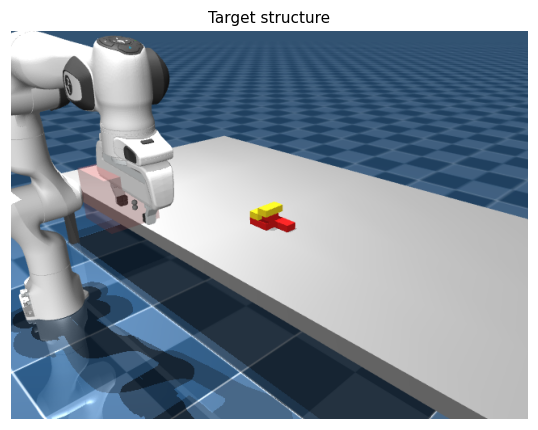

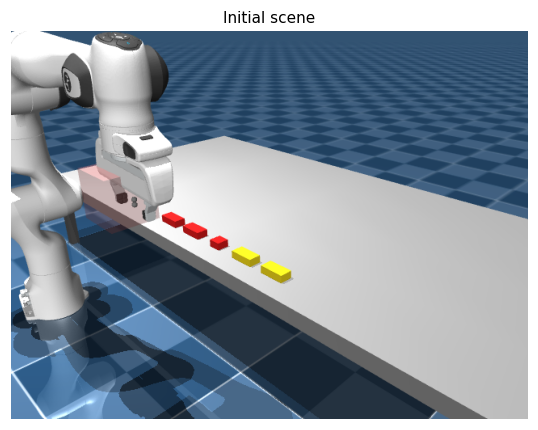

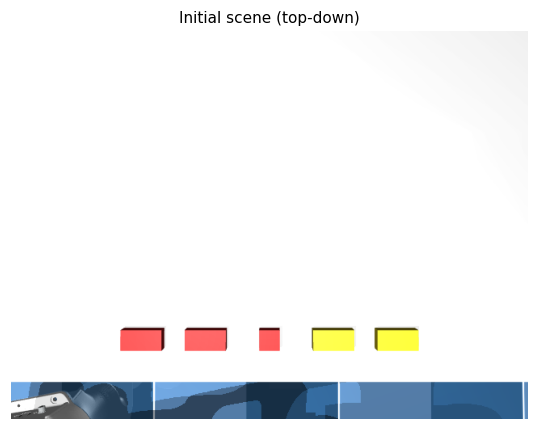

NOTE: To disable printing of planning engine credits, add this line to your code: `up.shortcuts.get_environment().credits_stream = None`
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/u/prak10/lab/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.


PLAN:
  ('pick', ('b_4x2_brick_2',))
  ('place', ('b_4x2_brick_2', 'l0', 'n2', 'n1'))
  ('pick', ('b_4x2_brick_1',))
  ('place', ('b_4x2_brick_1', 'l0', 'n1', 'n0'))
  ('open-next-level', ('l0', 'l1', 'n0'))
  ('pick', ('b_2x2_brick_3',))
  ('stack', ('b_2x2_brick_3', 'b_4x2_brick_1', 'l1', 'n2', 'n1'))
  ('pick', ('b_4x2_bric

In [15]:
from bridges import LegoCoarseSimpleV2SLSWeldBridge

# try new domain/bridge
bridge = LegoCoarseSimpleV2SLSWeldBridge.make_bridge("domains/lego_coarse_simple_v2.pddl", scene)
objects, goals = LegoCoarseSimpleV2SLSWeldBridge.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)

scene.to_target_structure()
show_scene(scene.env, "Target structure")
scene.env.reset()
scene.env.rest(1.0)

# problem = bridge.build_up_problem(objects, bridge.ground_state(objects), goals, "debug")
# print(problem)

show_scene(scene.env, "Initial scene")
show_top_view(scene.env, title="Initial scene (top-down)")
plan = bridge.plan(objects, goals)
print("\nPLAN:")
for step in plan:
    print(" ", step)

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.1 mm
  pick SUCCESS
[1/12] pick(b_4x2_brick_2) -> ok


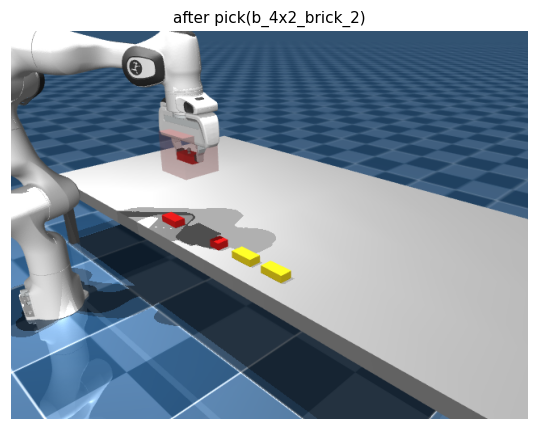

[2/12] place(b_4x2_brick_2, l0, n2, n1) -> ok


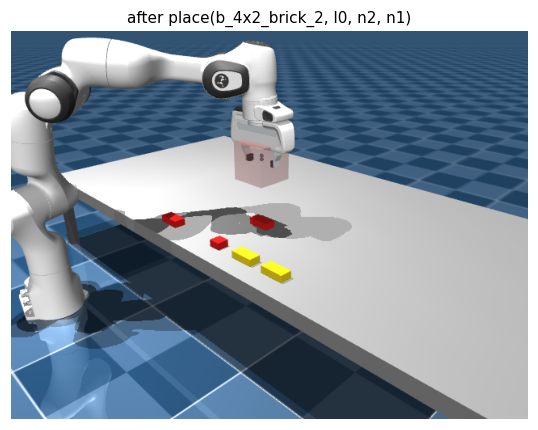

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.6 mm
  pick SUCCESS
[3/12] pick(b_4x2_brick_1) -> ok


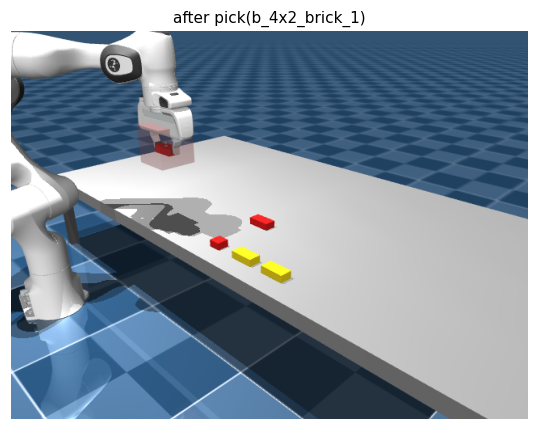

[4/12] place(b_4x2_brick_1, l0, n1, n0) -> ok


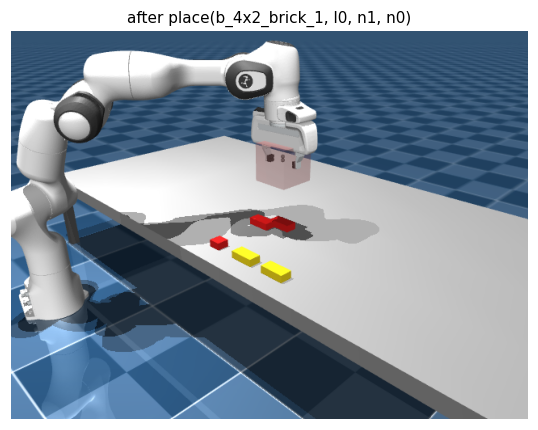

[5/12] open-next-level(l0, l1, n0) -> ok


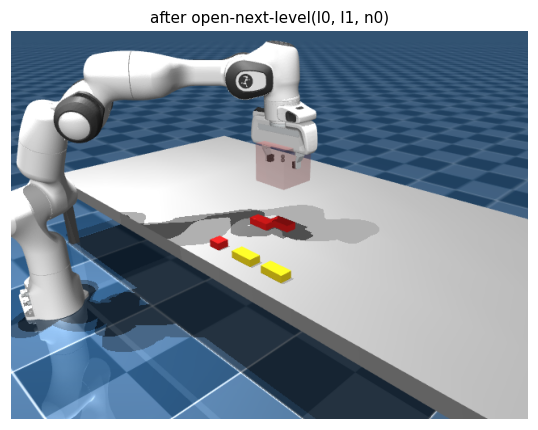

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.1 mm
  pick SUCCESS
[6/12] pick(b_2x2_brick_3) -> ok


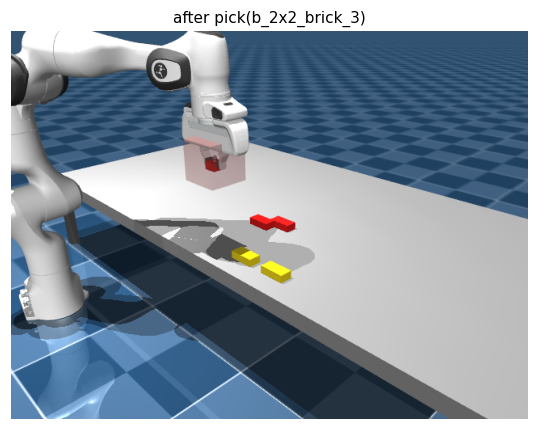

[7/12] stack(b_2x2_brick_3, b_4x2_brick_1, l1, n2, n1) -> ok


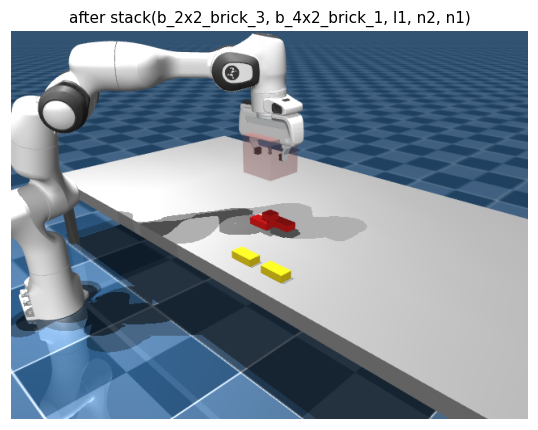

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.0 mm
  pick SUCCESS
[8/12] pick(b_4x2_brick_5) -> ok


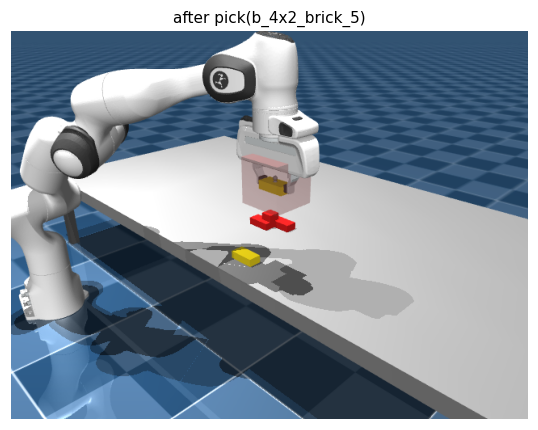

[9/12] stack(b_4x2_brick_5, b_4x2_brick_2, l1, n1, n0) -> ok


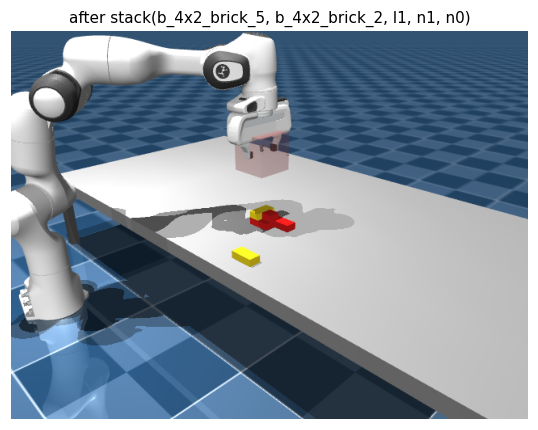

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 0.8 mm
  pick SUCCESS
[10/12] pick(b_4x2_brick_4) -> ok


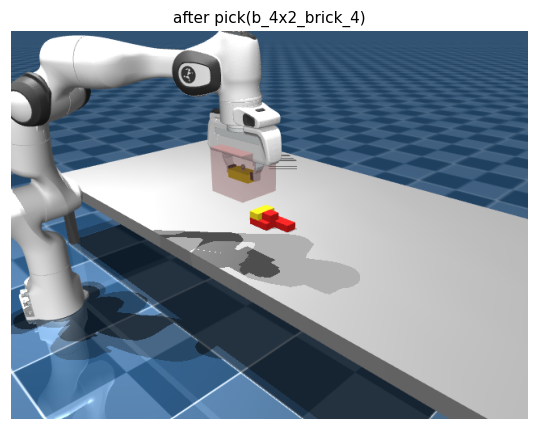

[11/12] open-next-level(l1, l2, n0) -> ok


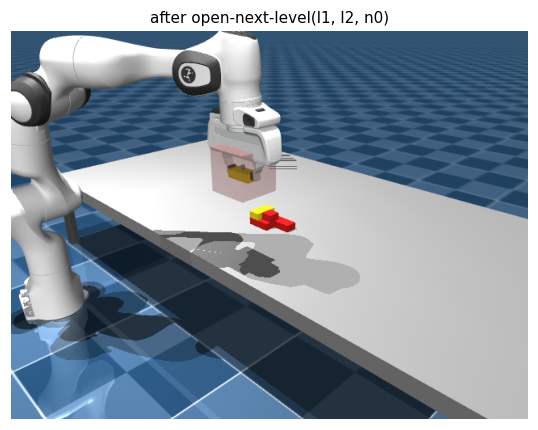

[12/12] stack(b_4x2_brick_4, b_2x2_brick_3, l2, n1, n0) -> ok


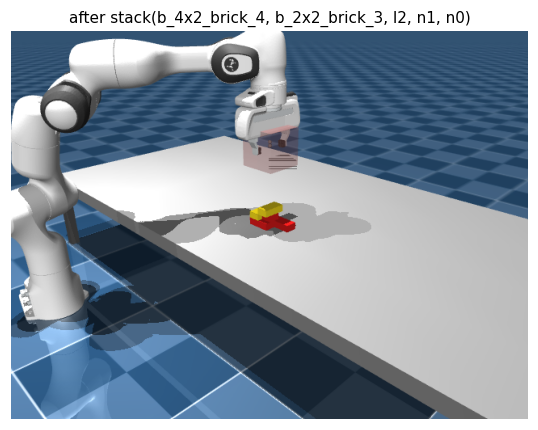


executed: True


In [16]:
scene.env.reset()
scene.env.rest(2.0)
viewer = scene.env.launch_viewer()

start_pos = scene.ee_pos()
ok, n = True, 0
for i, (name, args) in enumerate(plan):
    success, _ = bridge.execute_action(name, *args)
    print(f"[{i+1}/{len(plan)}] {name}({', '.join(args)}) -> {'ok' if success else 'FAILED'}")
    show_scene(scene.env, f"after {name}({', '.join(args)})")
    if not success:
        ok, n = False, i
        break
else:
    n = len(plan)

print("\nexecuted:", ok)

In [17]:
scene.check_goal()

(True,
 {'4x2_brick_1': (np.float64(3.6449914114765835e-07),
   np.float64(3.914543588129371e-05),
   8.129459700967345e-06,
   True),
  '4x2_brick_2': (np.float64(3.3837670047858403e-07),
   np.float64(3.915311135249677e-05),
   6.020037375265019e-06,
   True),
  '2x2_brick_3': (np.float64(2.9362097361591237e-07),
   np.float64(4.24915109764612e-08),
   8.376372051088765e-06,
   True),
  '4x2_brick_4': (np.float64(5.806647092569822e-13),
   np.float64(2.12875717053862e-10),
   3.5448692869977094e-09,
   True),
  '4x2_brick_5': (np.float64(1.1112100264173772e-07),
   np.float64(2.115704239580296e-08),
   2.7853557185153477e-06,
   True)})

## Full Sweep of Tier 2:

In [ ]:
import glob
SEED = 42

results = []

for i, task in enumerate(sorted(glob.glob("dataset/ground_truth/tier2/task_*.yaml"))):
    print(f"[{i+1}/100]: setting up {task}")
    bricks, lat = load_task(TASK, TASK)
    scene = SimpleLegoScene(bricks, seed=SEED)
    scene.env.ik.solver = "daqp"
    _table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above

    
    bridge = LegoCoarseSimpleV2SLSWeldBridge.make_bridge("domains/lego_coarse_simple_v2.pddl", scene)
    objects, goals = LegoCoarseSimpleV2SLSWeldBridge.build_objects_and_goal(bricks)
    # print("objects:", objects)
    # print("goals:  ", goals)

    plan = bridge.plan(objects, goals)
    execute_plan(bridge, plan)
    success, _ = scene.check_goal()
    results.append(success)
    print(f"\nsuccess: {success}")
    print("\n\n")

In [19]:
all(results)

NameError: name 'results' is not defined